In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# On ajoute le dossier parent au chemin pour pouvoir importer 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import DataLoader

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Exploration des Données (EDA) - Cybersécurité
Ce notebook analyse les flux réseaux utilisés pour l'entraînement des modèles IDS.
L'objectif est de comprendre la répartition des attaques et les corrélations entre les variables.

In [2]:
# CHOISIR LE DATASET ICI : 'nsl_kdd' ou 'cic_ids2017'
DATASET_NAME = 'cic_ids2017' 

print(f"Chargement du dataset : {DATASET_NAME}...")
loader = DataLoader(DATASET_NAME)

# On récupère les données (Normalisées par le DataLoader)
X_train, X_test, y_train, y_test = loader.load_data()

# Pour l'analyse, on recombine X et y du set d'entrainement dans un seul DataFrame
df_analysis = X_train.copy()
df_analysis['TARGET'] = y_train.values # 0 = Normal, 1 = Attaque

print(f"Dimensions des données d'analyse : {df_analysis.shape}")
df_analysis.head()

Chargement du dataset : cic_ids2017...
Chargement des données locales pour : cic_ids2017...
Dimensions des données d'analyse : (414843, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,TARGET
0,-0.356643,1.335987,-0.010023,-0.010277,-0.090208,-0.007586,-0.385147,-0.298255,-0.383899,-0.365671,...,0.829260,-0.130266,-0.101184,-0.148264,-0.102661,1.654138,-0.105504,1.628181,1.666023,1
1,-0.356643,-0.656225,-0.010023,-0.010277,-0.090208,-0.007586,-0.385147,-0.298255,-0.383899,-0.365671,...,0.829260,-0.130266,-0.101184,-0.148264,-0.102661,-0.581132,-0.105504,-0.586366,-0.571965,1
2,-0.356643,1.643200,-0.003334,-0.004213,-0.027710,-0.002229,0.238191,-0.298255,-0.035739,0.262060,...,-1.068172,-0.130261,-0.101184,-0.148261,-0.102656,1.997421,-0.105504,1.968282,2.009723,1
3,-0.356643,0.818866,-0.003334,-0.010277,-0.090208,-0.007586,-0.385147,-0.298255,-0.383899,-0.365671,...,2.094214,9.827277,-0.101184,6.268861,11.365330,-0.091102,2.615499,0.247010,-0.361653,1
4,-0.358359,-0.656218,-0.010023,-0.008256,-0.079819,-0.007513,-0.332517,0.340235,-0.181333,-0.365671,...,-1.068172,-0.130266,-0.101184,-0.148264,-0.102661,-0.581132,-0.105504,-0.586366,-0.571965,0


C:\Users\flavi\AppData\Local\Temp\ipykernel_21804\246144921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='TARGET', data=df_analysis, palette='viridis')


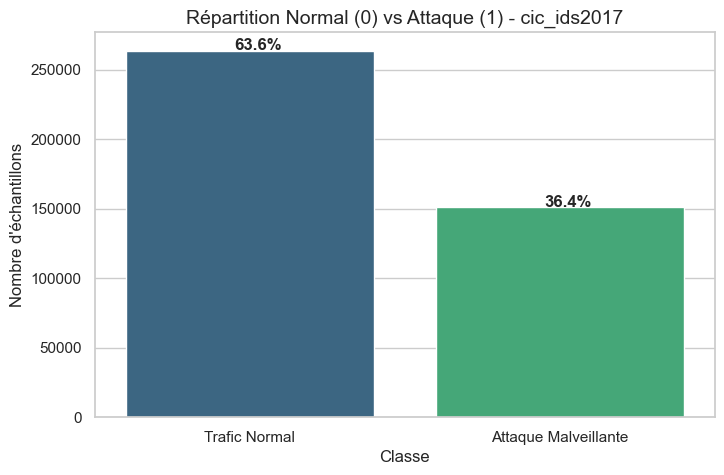

In [3]:
# Vérification du déséquilibre des classes (Class Imbalance)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='TARGET', data=df_analysis, palette='viridis')

# Ajout des étiquettes
plt.title(f"Répartition Normal (0) vs Attaque (1) - {DATASET_NAME}", fontsize=14)
plt.xlabel("Classe")
plt.ylabel("Nombre d'échantillons")
plt.xticks([0, 1], ['Trafic Normal', 'Attaque Malveillante'])

# Affichage des pourcentages
total = len(df_analysis)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 150
    ax.annotate(percentage, (x, y), size=12, weight='bold')

plt.show()

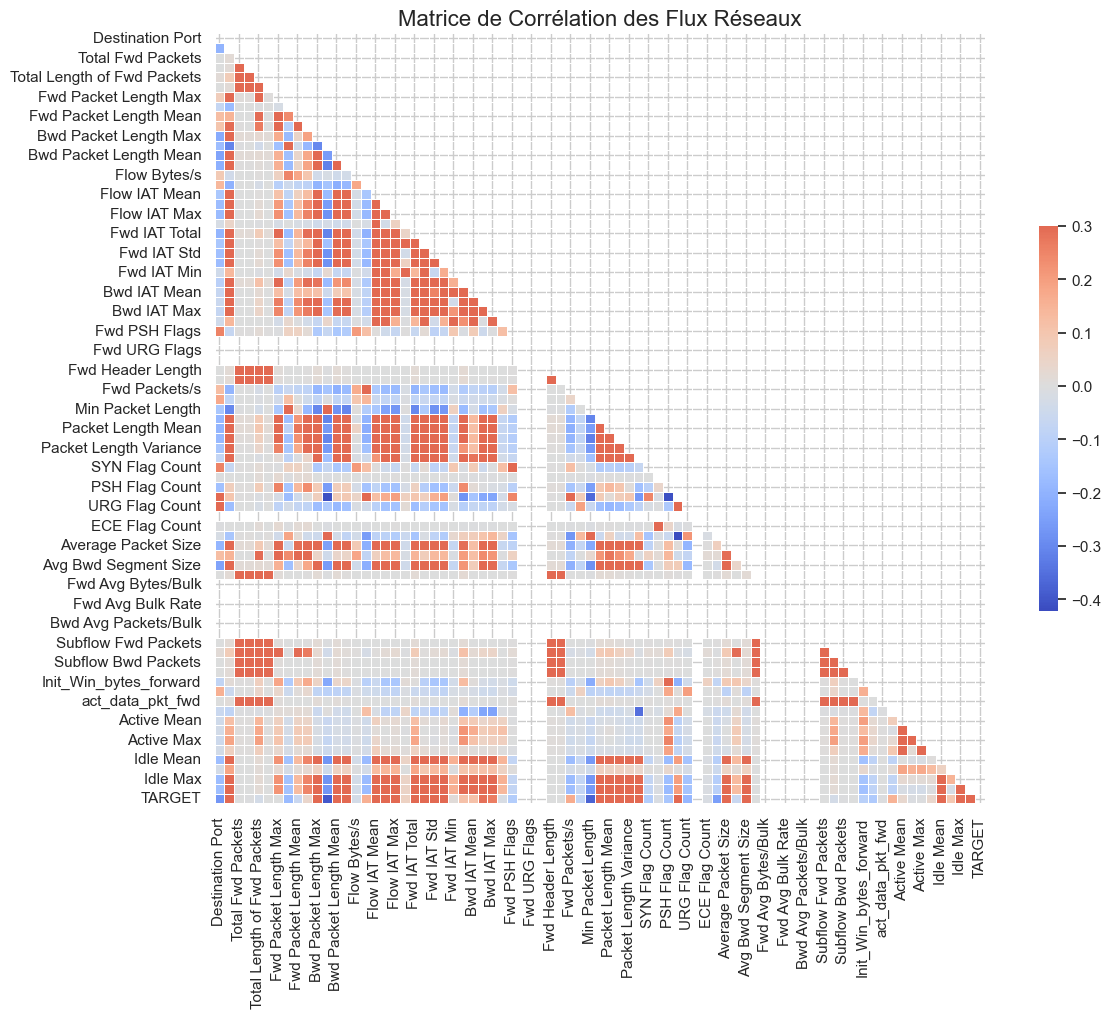

In [4]:
# Analyse des corrélations entre les features
# Cela permet de voir quelles variables "bougent ensemble" et quelles variables sont liées à la cible (TARGET)

# On calcule la corrélation (peut prendre quelques secondes)
corr_matrix = df_analysis.corr()

plt.figure(figsize=(14, 10))
# Masque pour ne pas afficher le triangle supérieur (doublon)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title("Matrice de Corrélation des Flux Réseaux", fontsize=16)
plt.show()

TOP 10 des variables les plus liées aux attaques :
TARGET                    1.000000
Bwd Packet Length Mean    0.640686
Avg Bwd Segment Size      0.640686
Bwd Packet Length Std     0.637505
Bwd Packet Length Max     0.632428
Packet Length Std         0.626573
Idle Max                  0.626018
Fwd IAT Std               0.624804
Fwd IAT Max               0.623889
Flow IAT Max              0.623309
Name: TARGET, dtype: float64


C:\Users\flavi\AppData\Local\Temp\ipykernel_21804\1571127842.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y=top_feature, data=df_analysis, palette='Set2')


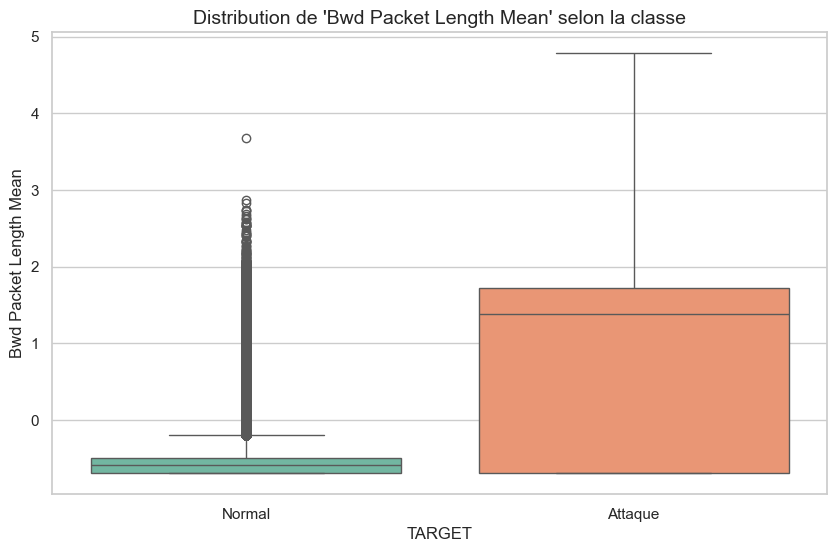

In [5]:
# Quelles sont les variables qui impactent le plus la décision "Attaque" ?
# On regarde la corrélation absolue avec la colonne TARGET
correlations = df_analysis.corr()['TARGET'].abs().sort_values(ascending=False)

print("TOP 10 des variables les plus liées aux attaques :")
print(correlations.head(10))

# Visualisation (Boxplot) de la feature la plus importante (hors Target)
top_feature = correlations.index[1] # L'index 0 est TARGET, le 1 est la meilleure feature

plt.figure(figsize=(10, 6))
sns.boxplot(x='TARGET', y=top_feature, data=df_analysis, palette='Set2')
plt.title(f"Distribution de '{top_feature}' selon la classe", fontsize=14)
plt.xticks([0, 1], ['Normal', 'Attaque'])
plt.show()